# SVD Tabanlı Dupe Finder
TF-IDF + Cosine (mevcut) vs **TF-IDF + SVD + Cosine** (yeni) karşılaştırmalı deney

In [ ]:
print("Gerekli kütüphaneler içe aktarılıyor.")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

Gerekli kütüphaneler içe aktarılıyor.


In [ ]:
print("Veri yükleniyor.")
products_url = "https://raw.githubusercontent.com/bengubal/cosmetic-dupe-finder/refs/heads/main/data/cleaned_products.csv"
df_products = pd.read_csv(products_url)
df = df_products
print(f"Veri seti boyutu: {df.shape}")
df[['product_name', 'brand_name', 'price_usd', 'rating', 'reviews']].head()

Veri yükleniyor.
Veri seti boyutu: (2999, 11)


,product_name,brand_name,price_usd,rating,reviews
0,Baomint Deep Conditioning Treatment,adwoa beauty,39.0,4.5273,311.0
1,Blue Tansy Reparative Mask,adwoa beauty,40.0,4.7581,492.0
2,Baomint Leave In Conditioning Styler,adwoa beauty,26.0,4.3472,144.0
3,Blue Tansy Leave in Conditioning Styler,adwoa beauty,26.0,4.5762,210.0
4,Baomint Moisturizing Shampoo,adwoa beauty,24.0,4.1324,136.0


In [ ]:
print("TF-IDF matrisi oluşturuluyor.")
df['text'] = (
    df['clean_ingredients'].fillna('') + ' ' +
    df['product_name'].fillna('')
)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['text'])

print(f"TF-IDF matris boyutu: {tfidf_matrix.shape}")

TF-IDF matrisi oluşturuluyor.
TF-IDF matris boyutu: (2999, 5000)


## Yöntem 1: TF-IDF + Cosine Similarity (Baseline)

In [ ]:
print("Yöntem 1: TF-IDF + Cosine Similarity hesaplanıyor (baseline).")
cosine_sim_tfidf = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Cosine similarity matris boyutu: {cosine_sim_tfidf.shape}")

Yöntem 1: TF-IDF + Cosine Similarity hesaplanıyor (baseline).
Cosine similarity matris boyutu: (2999, 2999)


## Yöntem 2: TF-IDF + SVD + Cosine Similarity

In [ ]:
print("Yöntem 2: TruncatedSVD ile boyut indirgeme yapılıyor.")
# n_components: kaç latent boyut? 100-300 arası iyi
svd = TruncatedSVD(n_components=100, random_state=42)
svd_matrix = svd.fit_transform(tfidf_matrix)

explained = svd.explained_variance_ratio_.sum()
print(f"SVD matris boyutu: {svd_matrix.shape}")
print(f"Açıklanan varyans oranı: %{explained*100:.1f}")

Yöntem 2: TruncatedSVD ile boyut indirgeme yapılıyor.
SVD matris boyutu: (2999, 100)
Açıklanan varyans oranı: %38.4


Açıklanan varyans oranı grafiği çiziliyor.


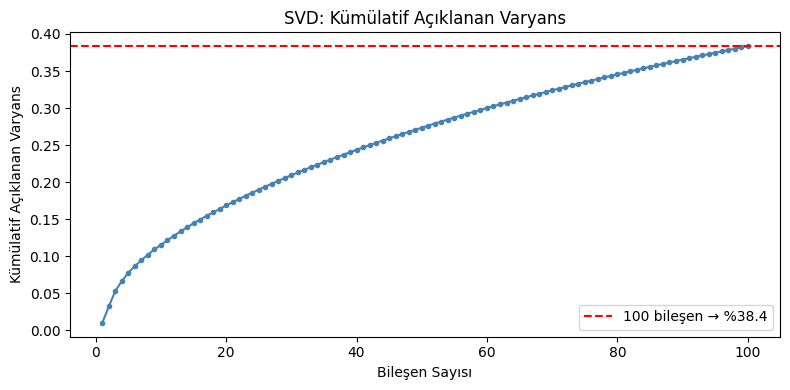

In [ ]:
print("Açıklanan varyans oranı grafiği çiziliyor.")
cumvar = np.cumsum(svd.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3, color='steelblue')
plt.axhline(y=explained, color='red', linestyle='--', label=f'100 bileşen → %{explained*100:.1f}')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Açıklanan Varyans')
plt.title('SVD: Kümülatif Açıklanan Varyans')
plt.legend()
plt.tight_layout()
plt.savefig('svd_explained_variance.png', dpi=150)
plt.show()

In [ ]:
print("SVD uzayında cosine similarity hesaplanıyor.")
cosine_sim_svd = cosine_similarity(svd_matrix, svd_matrix)
print(f"SVD Cosine similarity matris boyutu: {cosine_sim_svd.shape}")

SVD uzayında cosine similarity hesaplanıyor.
SVD Cosine similarity matris boyutu: (2999, 2999)


## Dupe Finder Fonksiyonu (Re-ranking ile)

In [ ]:
print("Fiyat ve rating re-ranking içeren dupe finder fonksiyonu tanımlanıyor.")

def find_dupes(product_id, sim_matrix, top_n=5, price_weight=0.4, rating_weight=0.6):
    """
    Verilen ürün için dupe'ları bulur ve fiyat + rating'e göre sıralar.

    Parametreler:
        product_id    : hedef ürün ID'si
        sim_matrix    : cosine_sim_tfidf veya cosine_sim_svd
        top_n         : kaç dupe döndürülsün
        price_weight  : fiyat ucuzluğunun ağırlığı (0-1)
        rating_weight : rating yüksekliğinin ağırlığı (0-1)
    """
    mask = df['product_id'] == product_id
    if not mask.any():
        print(f"Ürün bulunamadı: {product_id}")
        return None

    idx = df[mask].index[0]
    target_price = df.loc[idx, 'price_usd']
    target_brand = df.loc[idx, 'brand_name'].lower().strip()

    # Benzerlik skorlarını al, kendini çıkar
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n*20]  # geniş aday havuzu

    candidate_idx = [i[0] for i in sim_scores]
    candidate_sim = [i[1] for i in sim_scores]

    candidates = df.iloc[candidate_idx].copy()
    candidates['ingredient_similarity'] = candidate_sim

    # Filtreler: ucuz + farklı marka
    # Filtreler: hedef fiyatın %50'sinden ucuz + farklı marka
    candidates = candidates[
        (candidates['price_usd'] < target_price * 0.5) &
        (candidates['brand_name'].str.lower().str.strip() != target_brand)
    ]

    if candidates.empty:
        print("Uygun dupe bulunamadı.")
        return None

    # Re-ranking: fiyat + rating skoru
    scaler = MinMaxScaler()
    candidates['price_score']  = 1 - scaler.fit_transform(candidates[['price_usd']])
    candidates['rating_score'] = scaler.fit_transform(candidates[['rating']])
    candidates['final_score']  = (
        price_weight  * candidates['price_score'] +
        rating_weight * candidates['rating_score']
    )

    result = candidates.sort_values('final_score', ascending=False).head(top_n)

    return result[[
        'product_id', 'product_name', 'brand_name',
        'price_usd', 'rating', 'reviews',
        'ingredient_similarity', 'price_score', 'rating_score', 'final_score'
    ]].reset_index(drop=True)

Fiyat ve rating re-ranking içeren dupe finder fonksiyonu tanımlanıyor.


## Karşılaştırmalı Deney

In [ ]:
print("Karşılaştırmalı deney: pahalı bir ürün seçiliyor.")

# En pahalı ürünlerden birini seç
sample = df.nlargest(10, 'price_usd').iloc[0]
sample_id = sample['product_id']

print("=" * 50)
print("HEdef ÜRÜN:")
print(f"  İsim   : {sample['product_name']}")
print(f"  Marka  : {sample['brand_name']}")
print(f"  Fiyat  : ${sample['price_usd']}")
print(f"  Rating : {sample['rating']}")
print("=" * 50)

Karşılaştırmalı deney: pahalı bir ürün seçiliyor.
HEdef ÜRÜN:
  İsim   : The Concentrate Serum
  Marka  : La Mer
  Fiyat  : $425.0
  Rating : 4.5187


In [ ]:
print("Yöntem 1 (TF-IDF + Cosine) sonuçları:")
results_tfidf = find_dupes(sample_id, cosine_sim_tfidf)
print(results_tfidf.to_string(index=False))

Yöntem 1 (TF-IDF + Cosine) sonuçları:
product_id                                                        product_name        brand_name  price_usd  rating  reviews  ingredient_similarity  price_score  rating_score  final_score
   P476571 Turbo Body Lotion Energizing Gel Moisturizer with Eucalyptus & Aloe        Jack Black      38.00  5.0000      1.0               0.260846     0.818182      1.000000     0.927273
   P504004                             Heavenly Hydration Pre-Shampoo Hair Oil        BondiBoost      29.99  4.9109    101.0               0.222001     0.874196      0.932937     0.909440
   P502024                                 Curl Conditioning Hair Oil-In-Cream         Curlsmith      12.00  4.7317     41.0               0.264243     1.000000      0.798058     0.878835
   P479832                                      Bond-Building Repair Treatment Bumble and bumble      35.00  4.8505    368.0               0.235892     0.839161      0.887476     0.868150
   P504073            

In [ ]:
print("Yöntem 2 (TF-IDF + SVD + Cosine) sonuçları:")
results_svd = find_dupes(sample_id, cosine_sim_svd)
print(results_svd.to_string(index=False))

Yöntem 2 (TF-IDF + SVD + Cosine) sonuçları:
product_id                                                        product_name        brand_name  price_usd  rating  reviews  ingredient_similarity  price_score  rating_score  final_score
   P476571 Turbo Body Lotion Energizing Gel Moisturizer with Eucalyptus & Aloe        Jack Black       38.0  5.0000      1.0               0.598580     0.818182      1.000000     0.927273
   P502024                                 Curl Conditioning Hair Oil-In-Cream         Curlsmith       12.0  4.7317     41.0               0.395924     1.000000      0.789188     0.873513
   P479832                                      Bond-Building Repair Treatment Bumble and bumble       35.0  4.8505    368.0               0.433974     0.839161      0.882533     0.865184
   P504199                               Plankton + PHAFlower Acid Algae Serum              MARA       74.0  4.8846     52.0               0.401511     0.566434      0.909327     0.772169
   P481821      

## Karşılaştırma Görseli

İki yöntemin karşılaştırma grafiği çiziliyor.


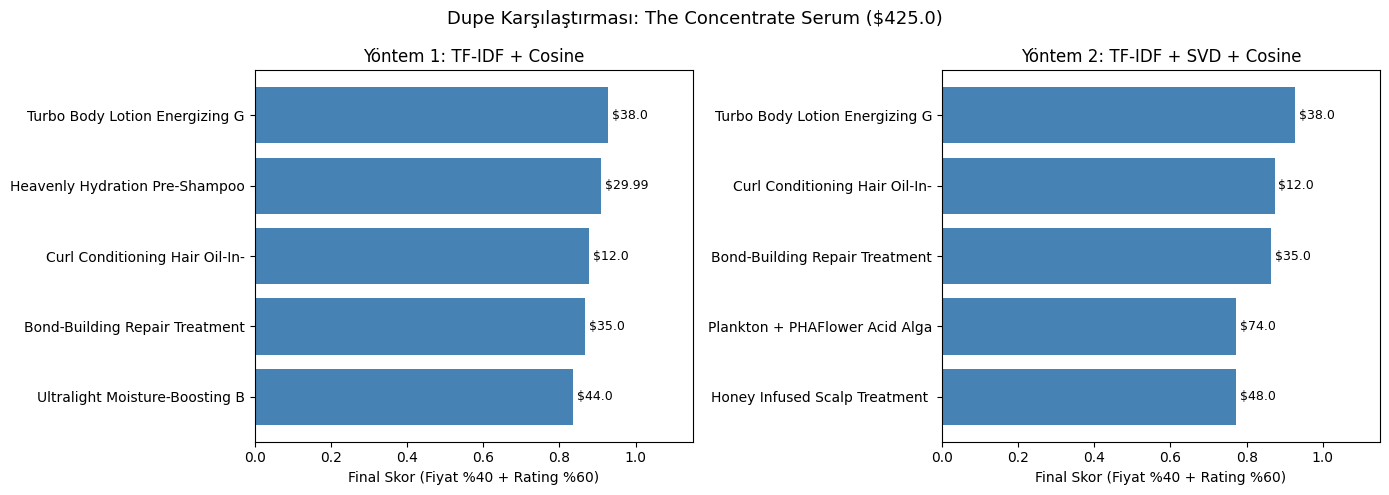

In [ ]:
print("İki yöntemin karşılaştırma grafiği çiziliyor.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Dupe Karşılaştırması: {sample["product_name"]} (${sample["price_usd"]})', fontsize=13)

for ax, (res, title) in zip(axes, [
    (results_tfidf, 'Yöntem 1: TF-IDF + Cosine'),
    (results_svd,   'Yöntem 2: TF-IDF + SVD + Cosine')
]):
    bars = ax.barh(
        res['product_name'].str[:30],
        res['final_score'],
        color='steelblue'
    )
    # Fiyat etiketleri
    for bar, price in zip(bars, res['price_usd']):
        ax.text(
            bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'${price}', va='center', fontsize=9
        )
    ax.set_xlabel('Final Skor (Fiyat %40 + Rating %60)')
    ax.set_title(title)
    ax.set_xlim(0, 1.15)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('dupe_comparison.png', dpi=150)
plt.show()

In [ ]:
print("İki yöntemin ortalama ingredient_similarity değerleri karşılaştırılıyor.")

comparison = pd.DataFrame({
    'Metrik': ['Ort. Benzerlik', 'Ort. Fiyat ($)', 'Ort. Rating', 'Ort. Final Skor'],
    'TF-IDF + Cosine': [
        results_tfidf['ingredient_similarity'].mean(),
        results_tfidf['price_usd'].mean(),
        results_tfidf['rating'].mean(),
        results_tfidf['final_score'].mean()
    ],
    'TF-IDF + SVD + Cosine': [
        results_svd['ingredient_similarity'].mean(),
        results_svd['price_usd'].mean(),
        results_svd['rating'].mean(),
        results_svd['final_score'].mean()
    ]
})
print(comparison.to_string(index=False))

İki yöntemin ortalama ingredient_similarity değerleri karşılaştırılıyor.
         Metrik  TF-IDF + Cosine  TF-IDF + SVD + Cosine
 Ort. Benzerlik         0.243609               0.457244
 Ort. Fiyat ($)        31.798000              41.400000
    Ort. Rating         4.865820               4.839180
Ort. Final Skor         0.884025               0.841945


---
# 3. K-Means Kümeleme ile Dupe Filtreleme
> Bu bölümde ürünler SVD matrisinden K-Means ile kümelere ayrılır. Dupe araması yalnızca hedef ürünle aynı kümedeki ürünler içinde yapılır.

In [ ]:
print('K-Means icin en iyi k, Silhouette skoruyla belirleniyor.')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}
for k in range(3, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(svd_matrix)
    score = silhouette_score(svd_matrix, labels, sample_size=1000, random_state=42)
    silhouette_scores[k] = score
    print(f'  k={k}  silhouette={score:.4f}')

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f'\nEn iyi k: {best_k}  (silhouette={silhouette_scores[best_k]:.4f})')

K-Means icin en iyi k, Silhouette skoruyla belirleniyor.
  k=3  silhouette=0.0512
  k=4  silhouette=0.0429
  k=5  silhouette=0.0476
  k=6  silhouette=0.0427
  k=7  silhouette=0.0447
  k=8  silhouette=0.0479
  k=9  silhouette=0.0487
  k=10  silhouette=0.0482
  k=11  silhouette=0.0471

En iyi k: 3  (silhouette=0.0512)


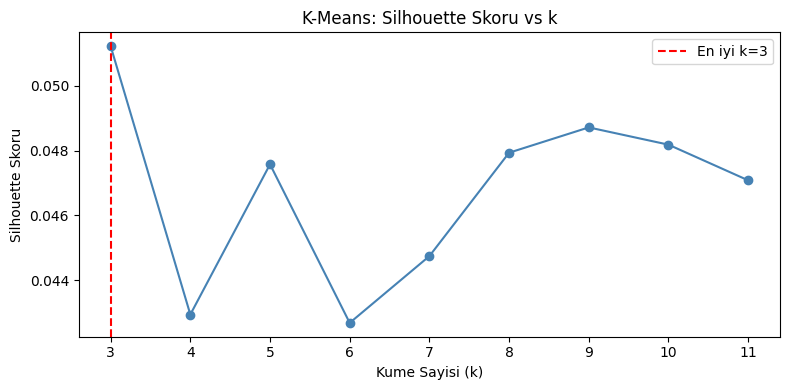

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'En iyi k={best_k}')
plt.xlabel('Kume Sayisi (k)')
plt.ylabel('Silhouette Skoru')
plt.title('K-Means: Silhouette Skoru vs k')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_silhouette.png', dpi=150)
plt.show()

In [ ]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = final_km.fit_predict(svd_matrix)
print('Kume dagilimi:')
print(df['cluster'].value_counts().sort_index())

Kume dagilimi:
cluster
0     592
1    1682
2     725
Name: count, dtype: int64


---
# 4. Duygu Analizi — Naive Bayes Sınıflandırıcı
> `cleaned_reviews.csv` üzerinde Naive Bayes ile binary sentiment sınıflandırması yapılır.
> `rating >= 4` → pozitif (1), `rating <= 2` → negatif (0) olarak etiketlenir.
> Model eğitildikten sonra her ürün için pozitif yorum oranı hesaplanır ve `sentiment_score` oluşturulur.
> **Metrikler:** Accuracy, Precision, Recall, F1-score, Confusion Matrix

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer as _TfReview
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import seaborn as sns
print('Naive Bayes icin kutuphaneler yuklendi.')

Naive Bayes icin kutuphaneler yuklendi.


In [ ]:
print('cleaned_reviews.csv yukleniyor...')
REVIEWS_URL = 'https://raw.githubusercontent.com/bengubal/cosmetic-dupe-finder/main/data/cleaned_reviews.csv'
reviews_df = pd.read_csv(REVIEWS_URL)
print(f'Yorum sayisi: {len(reviews_df)}')
print(f'Sutunlar: {list(reviews_df.columns)}')
reviews_df.head(3)

cleaned_reviews.csv yukleniyor...
Yorum sayisi: 65759
Sutunlar: ['product_id', 'review_text', 'rating', 'is_recommended', 'helpfulness', 'clean_review_text']


,product_id,review_text,rating,is_recommended,helpfulness,clean_review_text
0,P504322,I use this with the Nudestix “Citrus Clean Bal...,5,1.0,1.0,i use this with the nudestix citrus clean balm...
1,P420652,I bought this lip mask after reading the revie...,1,0.0,NaN,i bought this lip mask after reading the revie...
2,P420652,My review title says it all! I get so excited ...,5,1.0,NaN,my review title says it all i get so excited t...


In [ ]:
print('Yorum verisi etiketleniyor ve Naive Bayes egitiliyor...')

# Etiketleme: rating >= 4 pozitif, <= 2 negatif, aradakiler cikarilir
reviews_df['rating_num'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
labeled = reviews_df[reviews_df['rating_num'].isin([1, 2, 4, 5])].copy()
labeled['label'] = (labeled['rating_num'] >= 4).astype(int)
labeled = labeled[labeled['clean_review_text'].notna() & (labeled['clean_review_text'].str.strip() != '')]

print(f'Etiketli yorum sayisi: {len(labeled)}')
print(f'Pozitif: {labeled["label"].sum()}  |  Negatif: {(labeled["label"]==0).sum()}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    labeled['clean_review_text'], labeled['label'],
    test_size=0.2, random_state=42, stratify=labeled['label']
)

# TF-IDF vektorlestirme (yorum metni icin ayri vektorizer)
review_tfidf = _TfReview(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_vec = review_tfidf.fit_transform(X_train)
X_test_vec  = review_tfidf.transform(X_test)

# Naive Bayes egitimi
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_vec, y_train)

print('Model egitildi.')

Yorum verisi etiketleniyor ve Naive Bayes egitiliyor...
Etiketli yorum sayisi: 59890
Pozitif: 48429  |  Negatif: 11461
Model egitildi.


=== Naive Bayes Sentiment Modeli — Degerlendirme ===
Accuracy  : 0.9360
Precision : 0.9371
Recall    : 0.9872
F1-Score  : 0.9615

              precision    recall  f1-score   support

     Negatif       0.93      0.72      0.81      2292
     Pozitif       0.94      0.99      0.96      9686

    accuracy                           0.94     11978
   macro avg       0.93      0.85      0.89     11978
weighted avg       0.94      0.94      0.93     11978



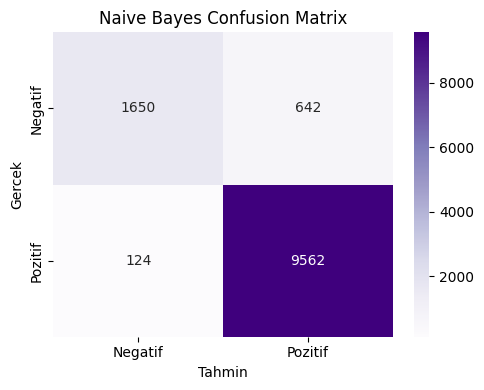

In [ ]:
# Degerlendirme metrikleri
y_pred = nb_model.predict(X_test_vec)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=== Naive Bayes Sentiment Modeli — Degerlendirme ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Pozitif']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'])
plt.xlabel('Tahmin')
plt.ylabel('Gercek')
plt.title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Tum yorumlar icin NB ile pozitif olasilik hesapla
all_texts = reviews_df['clean_review_text'].fillna('').astype(str)
all_vecs  = review_tfidf.transform(all_texts)
reviews_df['nb_positive_prob'] = nb_model.predict_proba(all_vecs)[:, 1]

# Urun bazinda agregasyon
product_sentiment = reviews_df.groupby('product_id').agg(
    sentiment_compound=('nb_positive_prob', 'mean'),
    sentiment_positive=('nb_positive_prob', lambda x: (x >= 0.5).mean()),
    review_count=('nb_positive_prob', 'count')
).reset_index()

print(f'Sentiment hesaplanan urun sayisi: {len(product_sentiment)}')
print(product_sentiment.head())

# df ile birlestir
if 'sentiment_compound' in df.columns:
    df = df.drop(columns=[c for c in ['sentiment_compound','sentiment_positive','review_count',
                                       'compound_norm','reviews_norm','rating_norm',
                                       'log_reviews','sentiment_score'] if c in df.columns])

df = df.merge(product_sentiment, on='product_id', how='left')

mean_compound = product_sentiment['sentiment_compound'].mean()
mean_positive = product_sentiment['sentiment_positive'].mean()
df['sentiment_compound'] = df['sentiment_compound'].fillna(mean_compound)
df['sentiment_positive'] = df['sentiment_positive'].fillna(mean_positive)
df['review_count']       = df['review_count'].fillna(0)

matched = (df['review_count'] > 0).sum()
print(f'Reviews eslesen urun: {matched} / {len(df)}')
print(f'Ortalama NB pozitif olasilik: {mean_compound:.4f} (eslesmeyenlere atandi)')

Sentiment hesaplanan urun sayisi: 1867
  product_id  sentiment_compound  sentiment_positive  review_count
0    P107306            0.693043               0.700            40
1    P114902            0.822984               0.875            40
2     P12045            0.891139               0.925            40
3    P122651            0.824220               0.875            40
4    P122661            0.794467               0.800            40
Reviews eslesen urun: 1867 / 2999
Ortalama NB pozitif olasilik: 0.7956 (eslesmeyenlere atandi)


In [ ]:
# sentiment_score: %50 NB pozitif olasilik + %30 rating + %20 popularlik
from sklearn.preprocessing import MinMaxScaler as _MMS2
_sc2 = _MMS2()

df['log_reviews']  = np.log1p(df['reviews'].fillna(0))
df['reviews_norm'] = _sc2.fit_transform(df[['log_reviews']])
df['rating_norm']  = _sc2.fit_transform(df[['rating']].fillna(0))

df['sentiment_score'] = (
    0.50 * df['sentiment_compound'] +
    0.30 * df['rating_norm'] +
    0.20 * df['reviews_norm']
)

print('Guncellenmis sentiment_score (Naive Bayes tabanli):')
print(df[['product_name', 'sentiment_compound', 'rating', 'sentiment_score']].head(10).to_string(index=False))

Guncellenmis sentiment_score (Naive Bayes tabanli):
                             product_name  sentiment_compound  rating  sentiment_score
      Baomint Deep Conditioning Treatment            0.795611  4.5273         0.774639
               Blue Tansy Reparative Mask            0.795611  4.7581         0.802122
     Baomint Leave In Conditioning Styler            0.795611  4.3472         0.744093
  Blue Tansy Leave in Conditioning Styler            0.795611  4.5762         0.769609
             Baomint Moisturizing Shampoo            0.795611  4.1324         0.726721
        Blue Tansy Clarifying Gel Shampoo            0.795611  4.3109         0.747844
Melonberry Hair Milk Leave-In Conditioner            0.795611  4.3826         0.794930
        Baomint Protect + Shine Oil Blend            0.795611  4.5359         0.769264
 Baomint Moisturizing Curl Defining Cream            0.795611  4.5635         0.772693
               Blue Tansy Treatment Serum            0.795611  4.6465         

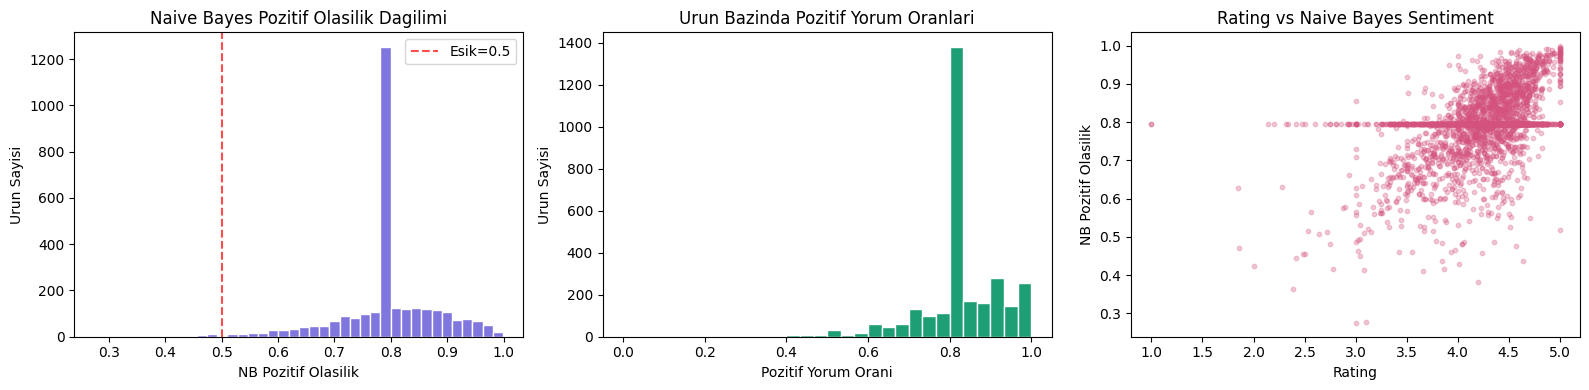

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. NB pozitif olasilik dagilimi
axes[0].hist(df['sentiment_compound'], bins=40, color='#7F77DD', edgecolor='white')
axes[0].set_xlabel('NB Pozitif Olasilik')
axes[0].set_ylabel('Urun Sayisi')
axes[0].set_title('Naive Bayes Pozitif Olasilik Dagilimi')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Esik=0.5')
axes[0].legend()

# 2. Pozitif yorum orani
axes[1].hist(df['sentiment_positive'], bins=30, color='#1D9E75', edgecolor='white')
axes[1].set_xlabel('Pozitif Yorum Orani')
axes[1].set_ylabel('Urun Sayisi')
axes[1].set_title('Urun Bazinda Pozitif Yorum Oranlari')

# 3. Rating vs NB compound scatter
axes[2].scatter(df['rating'], df['sentiment_compound'], alpha=0.3, color='#D4537E', s=10)
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('NB Pozitif Olasilik')
axes[2].set_title('Rating vs Naive Bayes Sentiment')

plt.tight_layout()
plt.savefig('nb_sentiment_analysis.png', dpi=150)
plt.show()

In [ ]:
print('=== En Yuksek NB Sentiment Skoru (Top 10) ===')
print(df.nlargest(10, 'sentiment_compound')[['product_name','brand_name','price_usd','rating','sentiment_compound','review_count']].to_string(index=False))

print('\n=== En Dusuk NB Sentiment Skoru (Bottom 10) ===')
print(df.nsmallest(10, 'sentiment_compound')[['product_name','brand_name','price_usd','rating','sentiment_compound','review_count']].to_string(index=False))

=== En Yuksek NB Sentiment Skoru (Top 10) ===
                                                  product_name      brand_name  price_usd  rating  sentiment_compound  review_count
           Revitalizing Supreme+ Bright Soft Creme Moisturizer    Estée Lauder       98.0  5.0000            0.998513           1.0
                          White Ginseng Radiance Refining Mask       Sulwhasoo       68.0  5.0000            0.994246           1.0
                                   Superkind Refining Cleanser     Tata Harper       88.0  5.0000            0.993149           1.0
                     Soft Clean Moisture Rich Foaming Cleanser    Estée Lauder       26.0  5.0000            0.992900           1.0
                    Equilibrium Resurfacing Retinoid Treatment       Hourglass      110.0  4.8898            0.990881          40.0
                                     Phyto Nature Oxygen Cream     Dermalogica      125.0  4.8646            0.990559          40.0
                              

---
# 5. Gelismis Dupe Finder: Kume + Fiyat + Yorum Filtreli
Uc katmanli filtreleme:
1. **K-Means kumesi** — yalnizca ayni kumedeki urunler
2. **Fiyat filtresi** — hedef fiyatin %50'sinden ucuz
3. **Yorum/sentiment filtresi** — minimum sentiment_score esigi

Final skor: `%50 ingredient_similarity + %30 sentiment_score + %20 price_score`

In [ ]:
def advanced_dupe_finder(
    product_name, df, svd_matrix,
    top_n=5, price_ratio=0.5, min_sentiment=0.3,
    min_rating=None, max_price=None,
    sort_by='ingredient_similarity'  # 'ingredient_similarity' | 'price' | 'sentiment'
):
    """
    SVD + K-Means + Sentiment tabanli dupe bulucu.

    Siralama mantigi:
    - Her zaman ONCE ingredient_similarity'ye gore sirala (buyukten kucuge)
    - sort_by='price'     -> ikincil siralama: price_usd (ucuzdan pahalia)
    - sort_by='sentiment' -> ikincil siralama: sentiment_score (yuksekten dusuge)
    - sort_by='ingredient_similarity' -> sadece benzerlik
    """
    mask = df['product_name'].str.contains(product_name.strip(), case=False, na=False)
    if mask.sum() == 0:
        print(f"'{product_name}' bulunamadi.")
        return None

    idx = df[mask].index[0]
    target = df.loc[idx]
    target_price   = target['price_usd']
    target_cluster = target['cluster']

    print(f"Hedef Urun  : {target['product_name']}")
    print(f"Marka       : {target['brand_name']}")
    print(f"Fiyat       : ${target_price}")
    print(f"Rating      : {target['rating']:.2f}")
    print(f"Kume        : {int(target_cluster)}")
    print(f"Siralama    : benzerlik (birincil) + {sort_by} (ikincil)")

    # SVD cosine similarity
    target_vec = svd_matrix[idx].reshape(1, -1)
    sim_scores = cosine_similarity(target_vec, svd_matrix).flatten()

    candidates = df.copy()
    candidates['ingredient_similarity'] = sim_scores

    # Filtreler
    candidates = candidates[candidates.index != idx]
    candidates = candidates[candidates['cluster'] == target_cluster]
    candidates = candidates[candidates['price_usd'] < target_price * price_ratio]
    candidates = candidates[candidates['sentiment_score'] >= min_sentiment]
    if min_rating is not None:
        candidates = candidates[candidates['rating'] >= min_rating]
    if max_price is not None:
        candidates = candidates[candidates['price_usd'] <= max_price]

    if candidates.empty:
        print("Uyari: Filtrelerle eslesen urun bulunamadi.")
        return None

    # Siralama: benzerlik her zaman birincil
    if sort_by == 'price':
        candidates = candidates.sort_values(
            ['ingredient_similarity', 'price_usd'],
            ascending=[False, True]
        )
    elif sort_by == 'sentiment':
        candidates = candidates.sort_values(
            ['ingredient_similarity', 'sentiment_score'],
            ascending=[False, False]
        )
    else:
        candidates = candidates.sort_values('ingredient_similarity', ascending=False)

    result = candidates.head(top_n)[[
        'product_name', 'brand_name', 'price_usd', 'rating',
        'ingredient_similarity', 'sentiment_score', 'sentiment_compound'
    ]].reset_index(drop=True)
    result.index += 1

    print(f"\nTop {top_n} Dupe | Birincil: benzerlik | Ikincil: {sort_by}")
    print(result.to_string())
    return result

print('advanced_dupe_finder tanimlandi.')

advanced_dupe_finder tanimlandi.


In [ ]:
sample_name = df.iloc[0]['product_name']

# --- Siralama 1: Icerik benzerligi (SVD cosine) ---
print('\n' + '='*60)
print('SIRALAMA 1: Icerik Benzerligi (SVD Cosine Similarity)')
print('='*60)
res_by_similarity = advanced_dupe_finder(
    product_name=sample_name, df=df, svd_matrix=svd_matrix,
    top_n=5, price_ratio=0.5, min_sentiment=0.3,
    sort_by='ingredient_similarity'
)


SIRALAMA 1: Icerik Benzerligi (SVD Cosine Similarity)
Hedef Urun  : Baomint Deep Conditioning Treatment
Marka       : adwoa beauty
Fiyat       : $39.0
Rating      : 4.53
Kume        : 0
Siralama    : benzerlik (birincil) + ingredient_similarity (ikincil)

Top 5 Dupe | Birincil: benzerlik | Ikincil: ingredient_similarity
                                          product_name                    brand_name  price_usd  rating  ingredient_similarity  sentiment_score  sentiment_compound
1                             Peppermint Essential Oil              SUNDAY II SUNDAY       15.0  5.0000               0.642180         0.697806            0.795611
2                             Mini Hydrate Conditioner                     Pureology       11.0  4.4808               0.520833         0.805481            0.795611
3             Mini Styling Cream for Curly &Coily Hair  PATTERN by Tracee Ellis Ross        9.0  3.4286               0.508424         0.624753            0.795611
4                    

In [ ]:
# --- Siralama 2: Fiyat (ucuzdan pahalia) ---
print('\n' + '='*60)
print('SIRALAMA 2: Fiyat (Ucuzdan Pahalia)')
print('='*60)
res_by_price = advanced_dupe_finder(
    product_name=sample_name, df=df, svd_matrix=svd_matrix,
    top_n=5, price_ratio=0.5, min_sentiment=0.3,
    sort_by='price'
)


SIRALAMA 2: Fiyat (Ucuzdan Pahalia)
Hedef Urun  : Baomint Deep Conditioning Treatment
Marka       : adwoa beauty
Fiyat       : $39.0
Rating      : 4.53
Kume        : 0
Siralama    : benzerlik (birincil) + price (ikincil)

Top 5 Dupe | Birincil: benzerlik | Ikincil: price
                                          product_name                    brand_name  price_usd  rating  ingredient_similarity  sentiment_score  sentiment_compound
1                             Peppermint Essential Oil              SUNDAY II SUNDAY       15.0  5.0000               0.642180         0.697806            0.795611
2                             Mini Hydrate Conditioner                     Pureology       11.0  4.4808               0.520833         0.805481            0.795611
3             Mini Styling Cream for Curly &Coily Hair  PATTERN by Tracee Ellis Ross        9.0  3.4286               0.508424         0.624753            0.795611
4                               Mini Hydration Shampoo  PATTERN by Trac

In [ ]:
# --- Siralama 3: Sentiment (yuksekten dusuge) ---
print('\n' + '='*60)
print('SIRALAMA 3: Sentiment Skoru (Yuksekten Dusuge)')
print('='*60)
res_by_sentiment = advanced_dupe_finder(
    product_name=sample_name, df=df, svd_matrix=svd_matrix,
    top_n=5, price_ratio=0.5, min_sentiment=0.3,
    sort_by='sentiment'
)


SIRALAMA 3: Sentiment Skoru (Yuksekten Dusuge)
Hedef Urun  : Baomint Deep Conditioning Treatment
Marka       : adwoa beauty
Fiyat       : $39.0
Rating      : 4.53
Kume        : 0
Siralama    : benzerlik (birincil) + sentiment (ikincil)

Top 5 Dupe | Birincil: benzerlik | Ikincil: sentiment
                                          product_name                    brand_name  price_usd  rating  ingredient_similarity  sentiment_score  sentiment_compound
1                             Peppermint Essential Oil              SUNDAY II SUNDAY       15.0  5.0000               0.642180         0.697806            0.795611
2                             Mini Hydrate Conditioner                     Pureology       11.0  4.4808               0.520833         0.805481            0.795611
3             Mini Styling Cream for Curly &Coily Hair  PATTERN by Tracee Ellis Ross        9.0  3.4286               0.508424         0.624753            0.795611
4                               Mini Hydration Shamp

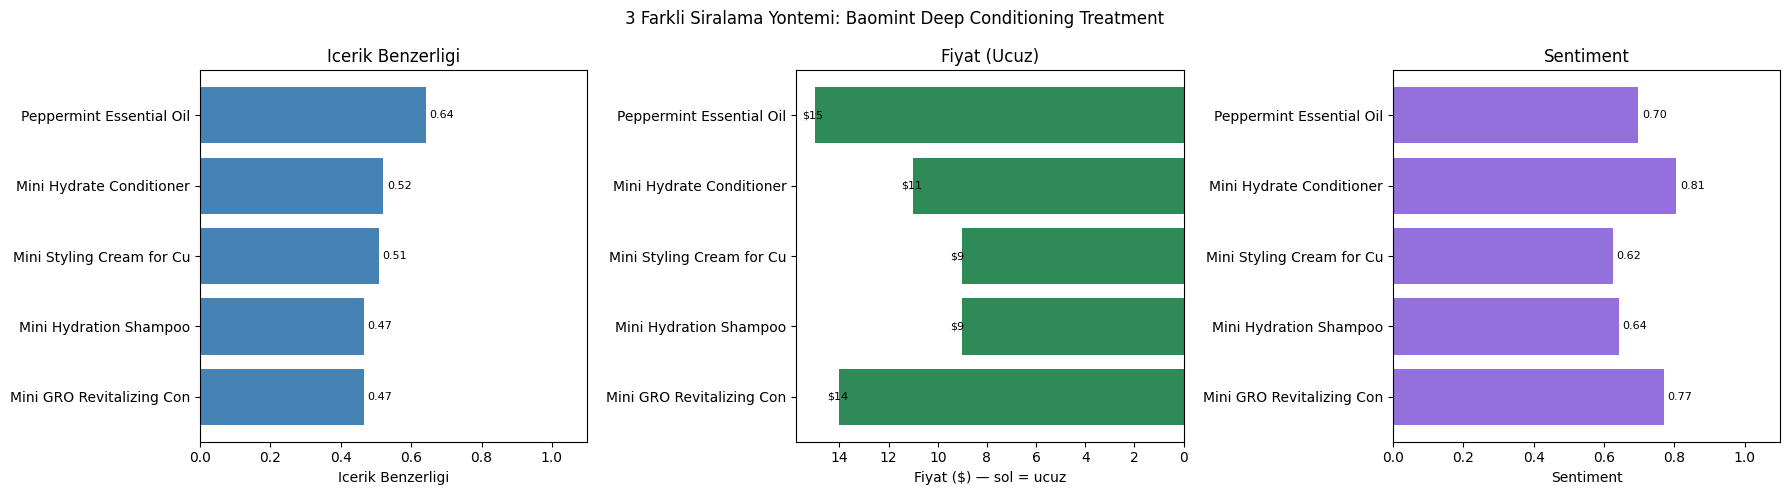

In [ ]:
# 3 farkli siralama yontemini gorsellestir
results_map = [
    (res_by_similarity, 'Icerik Benzerligi', 'ingredient_similarity', 'steelblue'),
    (res_by_price,      'Fiyat (Ucuz)',      'price_usd',             'seagreen'),
    (res_by_sentiment,  'Sentiment',         'sentiment_score',       'mediumpurple'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'3 Farkli Siralama Yontemi: {sample_name[:40]}', fontsize=12)

for ax, (res, title, col, color) in zip(axes, results_map):
    if res is None:
        ax.set_title(f'{title}\n(Sonuc yok)')
        continue
    vals = res[col]
    # Fiyat icin ekseni tersine cevir (ucuz = iyi)
    if col == 'price_usd':
        bars = ax.barh(res['product_name'].str[:25], vals, color=color)
        ax.invert_xaxis()
        ax.set_xlabel('Fiyat ($) — sol = ucuz')
    else:
        bars = ax.barh(res['product_name'].str[:25], vals, color=color)
        ax.set_xlim(0, 1.1)
        ax.set_xlabel(title)
    for bar, v in zip(bars, vals):
        label = f'${v:.0f}' if col == 'price_usd' else f'{v:.2f}'
        ax.text(bar.get_width() + (0.5 if col == 'price_usd' else 0.01),
                bar.get_y() + bar.get_height()/2,
                label, va='center', fontsize=8)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('dupe_sorting_comparison.png', dpi=150)
plt.show()

---
# 6. Uc Yontem Karsilastirma Ozeti
| Yontem | Filtre | Siralama | Metrik |
|--------|--------|----------|--------|
| TF-IDF + Cosine | Fiyat (%50) | ingredient_similarity | Cosine Similarity |
| TF-IDF + SVD + Cosine | Fiyat (%50) + Rating | final_score (agirlikli) | Cosine + Agirlikli Skor |
| SVD + K-Means + Sentiment | Kume + Fiyat + Yorum | final_score (3 faktorlu) | Silhouette + Agirlikli Skor |

In [ ]:
# Uc yontemin metrik karsilastirmasi
if res_by_similarity is not None:
    summary = pd.DataFrame({
        'Metrik': ['Ort. Icerik Benzerligi', 'Ort. Fiyat ($)', 'Ort. Rating', 'Ort. Sentiment Skoru'],
        'TF-IDF + Cosine': [
            results_tfidf['ingredient_similarity'].mean(),
            results_tfidf['price_usd'].mean(),
            results_tfidf['rating'].mean(),
            results_tfidf['final_score'].mean()
        ],
        'TF-IDF + SVD + Cosine': [
            results_svd['ingredient_similarity'].mean(),
            results_svd['price_usd'].mean(),
            results_svd['rating'].mean(),
            results_svd['final_score'].mean()
        ],
        'SVD + K-Means + NB Sentiment': [
            res_by_similarity['ingredient_similarity'].mean(),
            res_by_similarity['price_usd'].mean(),
            res_by_similarity['rating'].mean(),
            res_by_similarity['sentiment_score'].mean()
        ]
    })
    print('=' * 70)
    print('3 YONTEM KARSILASTIRMASI')
    print('=' * 70)
    print(summary.to_string(index=False))

3 YONTEM KARSILASTIRMASI
                Metrik  TF-IDF + Cosine  TF-IDF + SVD + Cosine  SVD + K-Means + NB Sentiment
Ort. Icerik Benzerligi         0.243609               0.457244                      0.520657
        Ort. Fiyat ($)        31.798000              41.400000                     11.600000
           Ort. Rating         4.865820               4.839180                      4.191480
  Ort. Sentiment Skoru         0.884025               0.841945                      0.707837


---
# 7. Gradio Arayüzü — SVD + K-Means + Sentiment
> Tüm pipeline (SVD cosine similarity → K-Means küme filtresi → sentiment filtresi → fiyat filtresi) Gradio arayüzüne bağlanır.
> `sort_by` parametresiyle içerik benzerliği, fiyat veya sentiment'e göre sıralama yapılabilir.

In [ ]:
try:
    import gradio as gr
    print('gradio mevcut.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gradio', '-q'])
    import gradio as gr
    print('gradio kuruldu.')

gradio mevcut.


In [ ]:
def dupe_finder_ui(product_name, sort_option):
    mask = df['product_name'].str.contains(product_name.strip(), case=False, na=False)
    if mask.sum() == 0:
        return f"'{product_name}' bulunamadi. Farkli bir isim deneyin.", None

    idx = df[mask].index[0]
    target = df.loc[idx]
    target_price   = target['price_usd']
    target_cluster = target['cluster']

    # Fiyat filtresini hedef fiyata gore dinamik belirle
    # Dusuk fiyatli urunlerde %50 cok siki olur, esnet
    if target_price <= 20:
        price_ratio = 0.9   # $20 alti → %90 alti
    elif target_price <= 40:
        price_ratio = 0.7   # $20-40 arasi → %70 alti
    else:
        price_ratio = 0.5   # $40 ustu → %50 alti

    # SVD cosine similarity
    target_vec = svd_matrix[idx].reshape(1, -1)
    sim_scores = cosine_similarity(target_vec, svd_matrix).flatten()

    candidate_df = df.copy()
    candidate_df['similarity'] = sim_scores
    candidate_df = candidate_df[candidate_df.index != idx]
    candidate_df = candidate_df[candidate_df['cluster'] == target_cluster]

    # En benzer 50 aday havuzu
    candidate_df = candidate_df.sort_values('similarity', ascending=False).head(50)

    # Fiyat filtresi (dinamik)
    candidate_df = candidate_df[candidate_df['price_usd'] <= target_price * price_ratio]

    # Sentiment filtresi
    candidate_df = candidate_df[candidate_df['sentiment_score'] >= 0.3]

    if candidate_df.empty:
        return (
            f"Hedef: {target['product_name']} (${target_price})\n"
            f"Fiyat filtresi: ${target_price * price_ratio:.1f} alti (oran: %{int(price_ratio*100)})\n"
            f"Filtrelerle eslesen urun bulunamadi.",
            None
        )

    # sort_option'a gore sirala
    if sort_option == 'Fiyat (Ucuzdan Pahalia)':
        candidate_df = candidate_df.sort_values('price_usd', ascending=True)
    elif sort_option == 'Sentiment Skoru':
        candidate_df = candidate_df.sort_values('sentiment_score', ascending=False)

    result = candidate_df.head(10)[[
        'product_name', 'brand_name', 'similarity',
        'price_usd', 'rating', 'sentiment_score'
    ]].copy().reset_index(drop=True)
    result.index += 1

    result['similarity']      = (result['similarity'] * 100).round(2)
    result['sentiment_score'] = result['sentiment_score'].round(4)

    result.columns = [
        'Urun Adi', 'Marka', 'Benzerlik (%)', 'Fiyat ($)', 'Rating', 'Sentiment Skoru'
    ]

    info = (
        f"Hedef Urun     : {target['product_name']}\n"
        f"Marka          : {target['brand_name']}\n"
        f"Fiyat          : ${target_price}\n"
        f"Rating         : {target['rating']:.2f}\n"
        f"Kume           : {int(target_cluster)}\n"
        f"Fiyat filtresi : ${target_price * price_ratio:.1f} alti (%{int(price_ratio*100)})\n"
        f"Aday havuzu    : en benzer 50 urun\n"
        f"Siralama       : {sort_option}"
    )

    return info, result

print('dupe_finder_ui tanimlandi.')

dupe_finder_ui tanimlandi.


In [61]:
import gradio as gr

custom_css = """
.gradio-container {
    background: linear-gradient(135deg, #fff0f3 0%, #f0faf4 50%, #e8f4ff 100%) !important;
    min-height: 100vh;
}
#title h1 {
    text-align: center;
    font-size: 2.4rem !important;
    font-weight: 800 !important;
    color: #d63384 !important;
    letter-spacing: -0.5px;
}
#subtitle p {
    text-align: center;
    color: #6b7280;
    font-size: 0.95rem;
    line-height: 1.7;
    margin: 0 auto;
    max-width: 520px;
}
#left-panel {
    background: white !important;
    border-radius: 20px !important;
    padding: 1.5rem !important;
    border: 1px solid #fce7f3 !important;
    box-shadow: 0 4px 20px rgba(214,51,132,0.08) !important;
}
#right-panel {
    background: white !important;
    border-radius: 20px !important;
    padding: 1.5rem !important;
    border: 1px solid #d1fae5 !important;
    box-shadow: 0 4px 20px rgba(16,185,129,0.08) !important;
}
#product-input textarea {
    border: 1.5px solid #fce7f3 !important;
    border-radius: 12px !important;
    font-size: 0.95rem !important;
}
#product-input textarea:focus {
    border-color: #d63384 !important;
    box-shadow: 0 0 0 3px rgba(214,51,132,0.1) !important;
}
#sort-radio fieldset {
    border: none !important;
    background: #fff5f8 !important;
    border-radius: 14px !important;
    padding: 0.75rem 1rem !important;
}
#search-btn button {
    width: 100% !important;
    border-radius: 14px !important;
    font-size: 1rem !important;
    font-weight: 700 !important;
    padding: 0.75rem !important;
    background: linear-gradient(135deg, #f472b6, #d63384) !important;
    color: white !important;
    border: none !important;
}
#search-btn button:hover {
    opacity: 0.9 !important;
    transform: translateY(-1px) !important;
}
#info-output textarea {
    background: #f8fffe !important;
    border: 1.5px solid #d1fae5 !important;
    border-radius: 12px !important;
    font-family: monospace !important;
    font-size: 0.85rem !important;
    color: #065f46 !important;
}
#result-table th {
    background: #fdf2f8 !important;
    color: #9d174d !important;
    font-weight: 600 !important;
    font-size: 0.8rem !important;
    text-transform: uppercase !important;
    letter-spacing: 0.04em !important;
    padding: 10px 12px !important;
}
#result-table tr:nth-child(even) td { background: #fdf9fc !important; }
#result-table tr:hover td { background: #fce7f3 !important; }
#result-table td {
    font-size: 0.85rem !important;
    padding: 9px 12px !important;
    color: #1f2937 !important;
}
"""

with gr.Blocks(
    title='Cosmetic Dupe Finder',
    theme=gr.themes.Soft(),
    css=custom_css
) as demo:

    with gr.Column(elem_id='title'):
        gr.Markdown('# ✨ Cosmetic Dupe Finder')

    with gr.Column(elem_id='subtitle'):
        gr.Markdown('En benzer 50 ürün içerik benzerliğiyle seçilir. Sıralama kriterini siz belirleyin.')

    with gr.Row():
        with gr.Column(scale=1, elem_id='left-panel'):
            product_input = gr.Textbox(
                label='🔍 Ürün Adı',
                placeholder='Örnek: Blue Tansy Reparative Mask',
                lines=1,
                elem_id='product-input'
            )
            sort_input = gr.Radio(
                choices=['Fiyat (Ucuzdan Pahalia)', 'Sentiment Skoru'],
                value='Fiyat (Ucuzdan Pahalia)',
                label='📊 Sıralama Kriteri',
                elem_id='sort-radio'
            )
            search_btn = gr.Button('✨ Dupe Bul', variant='primary', elem_id='search-btn')

        with gr.Column(scale=2, elem_id='right-panel'):
            info_output = gr.Textbox(
                label='📋 Hedef Ürün Bilgisi',
                lines=8,
                interactive=False,
                elem_id='info-output'
            )
            result_output = gr.Dataframe(
                label='🏆 Top 10 Dupe Önerisi',
                wrap=True,
                elem_id='result-table'
            )

    search_btn.click(
        fn=dupe_finder_ui,
        inputs=[product_input, sort_input],
        outputs=[info_output, result_output]
    )

    gr.Examples(
        examples=[
            ['Blue Tansy Reparative Mask', 'Fiyat (Ucuzdan Pahalia)'],
            ['Blue Tansy Reparative Mask', 'Sentiment Skoru'],
        ],
        inputs=[product_input, sort_input]
    )

demo.launch(share=True)

/tmp/ipykernel_3401/3818735329.py:92: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_3401/3818735329.py:92: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://324a9bd3e59751abdb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
